# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [3]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [4]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [5]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [6]:
no_training_epochs = 5

### 1.3 Data examination

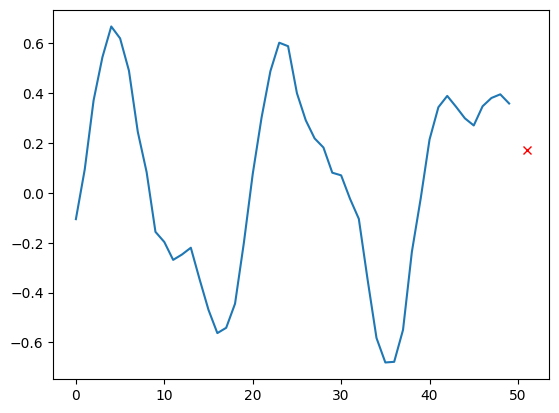

In [7]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [8]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [10]:
model_linear.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1511 - mean_squared_error: 0.1511 - val_loss: 0.0526 - val_mean_squared_error: 0.0526
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0342 - mean_squared_error: 0.0342 - val_loss: 0.0225 - val_mean_squared_error: 0.0225
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0176 - mean_squared_error: 0.0176 - val_loss: 0.0141 - val_mean_squared_error: 0.0141
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0120 - mean_squared_error: 0.0120 - val_loss: 0.0104 - val_mean_squared_error: 0.0104
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0094 - mean_squared_error: 0.0094 - val_loss: 0.0085 - val_mean_squared_error: 0.0085


In [12]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

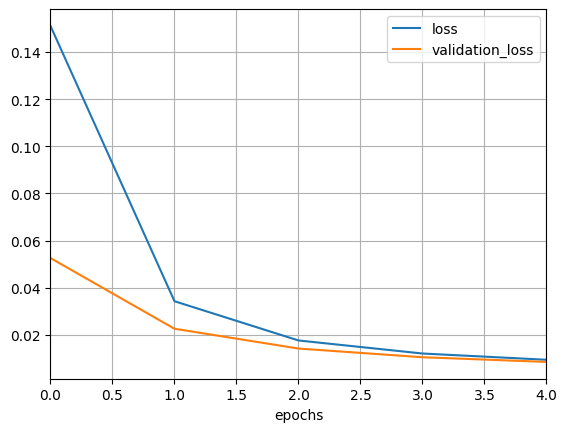

In [13]:
plot_function(history_linear)

In [14]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.008344149217009544
Test MSE:  0.008344149217009544


### 1.5 Simple RNN Model

In [15]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [17]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0482 - mean_squared_error: 0.0482 - val_loss: 0.0366 - val_mean_squared_error: 0.0366
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0307 - mean_squared_error: 0.0307 - val_loss: 0.0236 - val_mean_squared_error: 0.0236
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0201 - mean_squared_error: 0.0201 - val_loss: 0.0160 - val_mean_squared_error: 0.0160
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0144 - mean_squared_error: 0.0144 - val_loss: 0.0127 - val_mean_squared_error: 0.0127
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0121 - mean_squared_error: 0.0121 - val_loss: 0.0117 - val_mean_squared_error: 0.0117


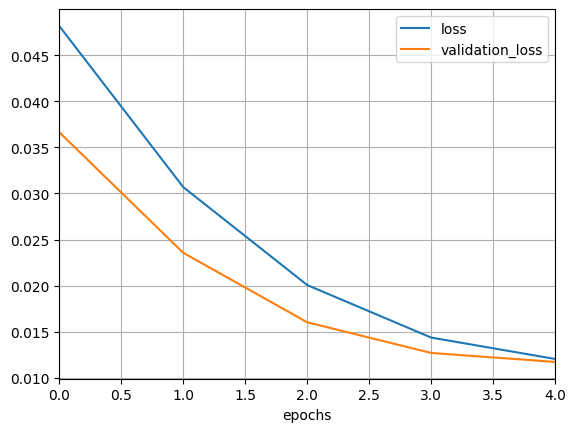

In [18]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [19]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [20]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [21]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 0.0217 - mean_squared_error: 0.0217 - val_loss: 0.0051 - val_mean_squared_error: 0.0051
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0032 - mean_squared_error: 0.0032 - val_loss: 0.0030 - val_mean_squared_error: 0.0030
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0031 - mean_squared_error: 0.0031 - val_loss: 0.0033 - val_mean_squared_error: 0.0033
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0030 - mean_squared_error: 0.0030 - val_loss: 0.0029 - val_mean_squared_error: 0.0029


In [22]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.0030697945039719343
Test MSE:  0.0030697945039719343


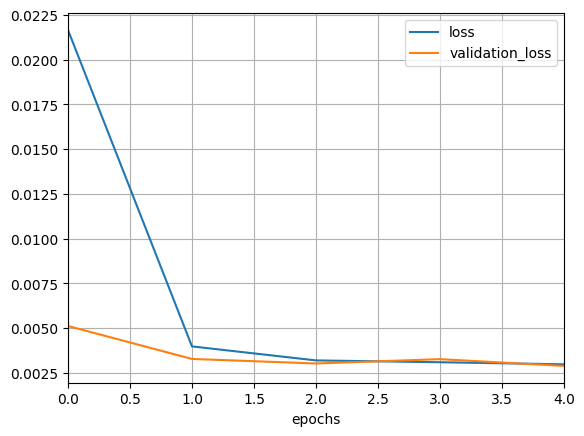

In [23]:
plot_function(history_deep_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [24]:
#from keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [25]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 2.2 - Dataset examination

In [26]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [27]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [28]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [29]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [30]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
optimizer = Adam(learning_rate = 0.001)

In [32]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [33]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5019 - loss: 0.7053 - val_accuracy: 0.4938 - val_loss: 0.6964
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4990 - loss: 0.6961 - val_accuracy: 0.4938 - val_loss: 0.6974
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4994 - loss: 0.6966 - val_accuracy: 0.5134 - val_loss: 0.6938
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4990 - loss: 0.6954 - val_accuracy: 0.4938 - val_loss: 0.6941
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.4983 - loss: 0.6956 - val_accuracy: 0.5062 - val_loss: 0.6938


In [34]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6946867108345032
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

In [35]:
# We are building a new Sequential model, replacing the SimpleRNN layers with LSTM layers.
# LSTMs have "memory cells" that help the network remember long-term context in movie reviews.
lstm_model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size, input_shape=[None]),
    keras.layers.LSTM(128, return_sequences=True),
    keras.layers.LSTM(128),
    keras.layers.Dense(1, activation='sigmoid')
])

# We are creating a fresh Adam optimizer for this model so it starts learning from scratch.
lstm_optimizer = Adam(learning_rate=0.001)

# We are compiling the model with binary crossentropy since we are predicting good (1) vs bad (0) reviews.
lstm_model.compile(loss="binary_crossentropy", optimizer=lstm_optimizer, metrics=["accuracy"])

# We are training the LSTM model on the training data for 5 epochs.
print("Training LSTM Model...")
history_lstm = lstm_model.fit(X_train, y_train, epochs=5, validation_split=0.2)

# We are evaluating the trained LSTM model on the test set to compare its accuracy against the SimpleRNN.
score_lstm = lstm_model.evaluate(X_test, y_test, verbose=0)
print('LSTM Test loss:', score_lstm[0])
print(f'LSTM Test accuracy: ', score_lstm[1]*100, "%")

Training LSTM Model...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.5612 - loss: 0.6816 - val_accuracy: 0.6904 - val_loss: 0.6098
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7104 - loss: 0.5577 - val_accuracy: 0.7984 - val_loss: 0.4542
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8154 - loss: 0.4153 - val_accuracy: 0.8044 - val_loss: 0.4246
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8368 - loss: 0.3751 - val_accuracy: 0.8200 - val_loss: 0.4024
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8453 - loss: 0.3578 - val_accuracy: 0.8104 - val_loss: 0.4193
LSTM Test loss: 0.41440096497535706
LSTM Test accuracy:  81.20399713516235 %


--- RESULTS SUMMARY ---


Test Loss Test Accuracy
Exercise    Model                                 
Time Series Simple Linear     0.0083           N/A
            Deep RNN          0.0030           N/A
IMDB (Text) Simple RNN        0.6946        50.00%
            LSTM              0.4144        81.20%

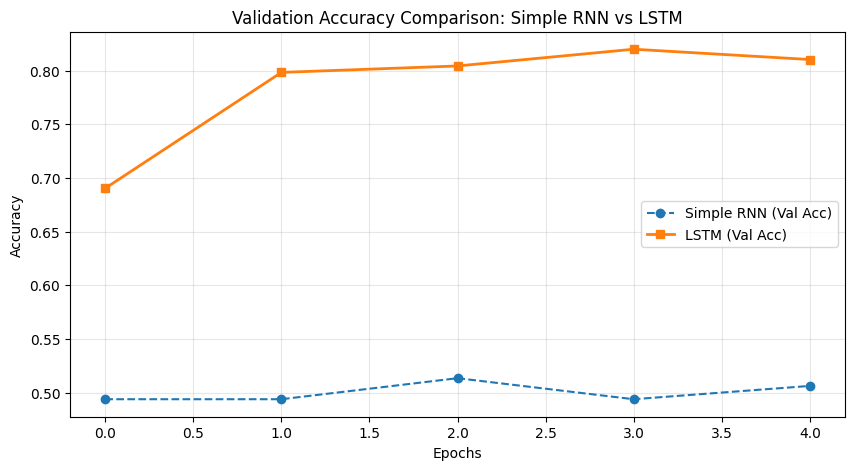

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a DataFrame with the final results to view them in a table format
comparison_data = {
    "Exercise": ["Time Series", "Time Series", "IMDB (Text)", "IMDB (Text)"],
    "Model": ["Simple Linear", "Deep RNN", "Simple RNN", "LSTM"],
    "Test Loss": [0.0083, 0.0030, 0.6946, 0.4144],
    "Test Accuracy": ["N/A", "N/A", "50.00%", "81.20%"]
}

df_results = pd.DataFrame(comparison_data)
df_results.set_index(["Exercise", "Model"], inplace=True)

print("--- RESULTS SUMMARY ---")
display(df_results)

print("\n" + "="*50 + "\n")

# 2. Plot the validation accuracy comparison for Exercise 2
# Note: This assumes the variables 'history' and 'history_lstm' are still in Colab's memory
try:
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['val_accuracy'], label='Simple RNN (Val Acc)', marker='o', linestyle='--')
    plt.plot(history_lstm.history['val_accuracy'], label='LSTM (Val Acc)', marker='s', linewidth=2)

    plt.title('Validation Accuracy Comparison: Simple RNN vs LSTM')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
except NameError:
    print("The training history variables are not in memory. Make sure you have run the training cells first.")